In [18]:
%config Completer.use_jedi = False
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import seaborn as sns
import cv2
import random
import os
import imageio
import plotly.graph_objects as go
import plotly.express as px
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
from collections import Counter
import platform

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, RepeatedStratifiedKFold
from imblearn.over_sampling import SMOTE

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization
from keras.applications import resnet

import warnings
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                      GlobalAveragePooling2D, Reshape,
                                      Multiply, Input, Layer)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

warnings.filterwarnings('ignore')

# CUDA / GPU setup (TensorFlow akan otomatis pakai GPU bila tersedia)
print(f'TensorFlow version: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'CUDA GPU terdeteksi: {[gpu.name for gpu in gpus]}')
    except RuntimeError as e:
        print(f'Peringatan konfigurasi GPU: {e}')
else:
    print('GPU CUDA tidak terdeteksi. Training akan berjalan di CPU.')
    tf_major, tf_minor = map(int, tf.__version__.split('.')[:2])
    if platform.system() == 'Windows' and (tf_major > 2 or (tf_major == 2 and tf_minor >= 11)):
        print('Catatan: TensorFlow >= 2.11 di Windows native tidak mendukung CUDA GPU.')
        print('Solusi: pakai WSL2 + CUDA, atau gunakan TensorFlow 2.10 + CUDA 11.2 + cuDNN 8.1.')

TensorFlow version: 2.10.0
CUDA GPU terdeteksi: ['/physical_device:GPU:0']


In [19]:
import numpy as np 
import pandas as pd 
import os
for folder in os.listdir('./archive'):
    if 'IQ-OTHNCCD' in folder or 'lung' in folder.lower():
        directory = os.path.join('./archive', folder)
        break
print(f"Dataset path: {directory}")
categories = ['Bengin cases', 'Malignant cases', 'Normal cases']

Dataset path: ./archive\The IQ-OTHNCCD lung cancer dataset


Bengin cases - Bengin case (1).jpg
Malignant cases - Malignant case (1).jpg
Normal cases - Normal case (1).jpg


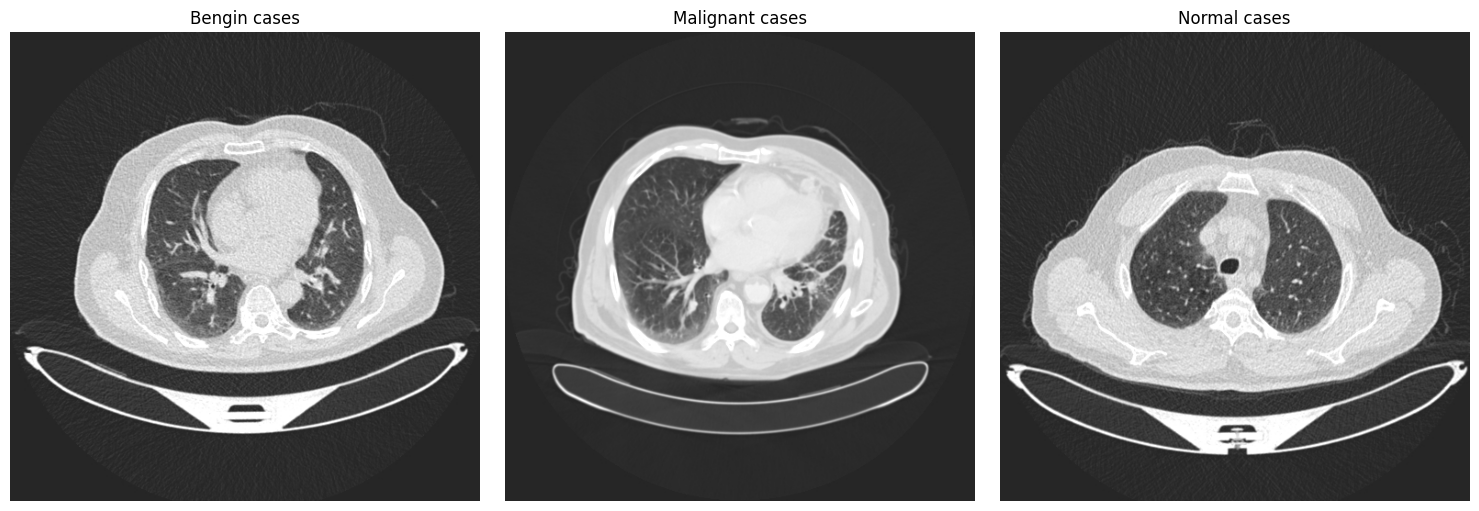

In [20]:
fig, axes = plt.subplots(1, len(categories), figsize=(15, 5))

for i, category in enumerate(categories):
    path = os.path.join(directory, category)
    # Loop files but break after the first one to show just one sample
    if not os.path.isdir(path):
        nested_path = os.path.join(directory, os.path.basename(directory), category)
        if os.path.isdir(nested_path):
            path = nested_path
        else:
            print(f"Folder tidak ditemukan: {path}")
            axes[i].axis('off')
            continue

    for file in os.listdir(path):
        filepath = os.path.join(path, file)
        print(category, '-', file)

        # Baca image asli (BGR) dan konversi ke RGB
        img = cv2.imread(filepath)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Tampilkan di subplot yang sesuai
        axes[i].imshow(img)
        axes[i].set_title(f'{category}')
        axes[i].axis('off')
        break

plt.tight_layout()
plt.show()

In [21]:
size_data = {}
for i in categories:
    path = os.path.join(directory, i)
    if not os.path.isdir(path):
        nested_path = os.path.join(directory, os.path.basename(directory), i)
        path = nested_path if os.path.isdir(nested_path) else None
    
    if path:
        temp_dict = {}
        for file in os.listdir(path):
            filepath = os.path.join(path, file)
            h, w, c = imageio.imread(filepath).shape
            key = f'{h} x {w}'
            temp_dict[key] = temp_dict.get(key, 0) + 1
        size_data[i] = temp_dict

print("="*60)
print("DISTRIBUSI UKURAN GAMBAR")
print("="*60)
for cat, sizes in size_data.items():
    df = pd.DataFrame([(k, v) for k, v in sorted(sizes.items(), key=lambda x: x[1], reverse=True)], 
                      columns=['Ukuran', 'Jumlah'])
    print(f"\n{cat}: {df['Jumlah'].sum()} total")
    print(df.to_string(index=False))


DISTRIBUSI UKURAN GAMBAR

Bengin cases: 120 total
   Ukuran  Jumlah
512 x 512     120

Malignant cases: 561 total
   Ukuran  Jumlah
512 x 512     501
512 x 623      31
512 x 801      28
404 x 511       1

Normal cases: 416 total
   Ukuran  Jumlah
512 x 512     415
331 x 506       1


────────────────────────────────────────────────────────────
✓ DATA BERHASIL DIMUAT
────────────────────────────────────────────────────────────
Total X shape    : (1097, 224, 224, 3)  (jumlah × tinggi × lebar × channel)
Label distribution: {2: 416, 1: 561, 0: 120} (jumlah per kategori)
────────────────────────────────────────────────────────────


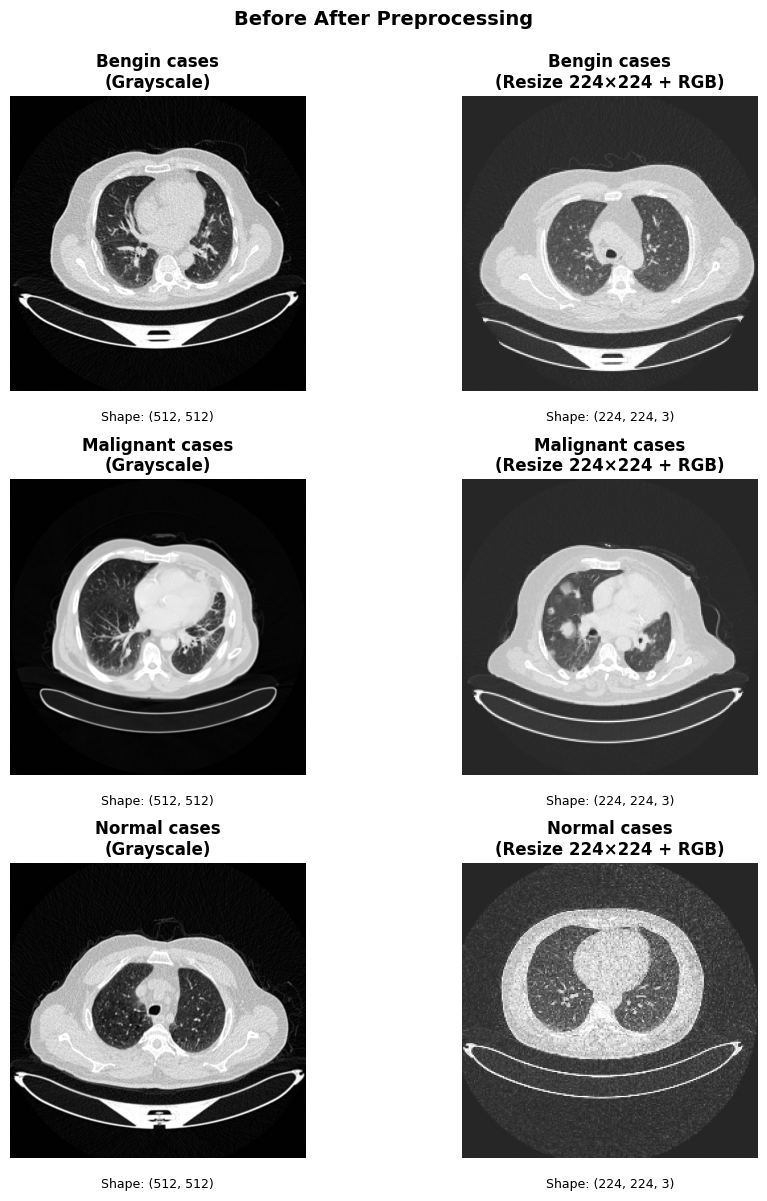

In [22]:
# ═══════════════════════════════════════════════════════════════════════════
# TAHAP 1: INISIALISASI & KONFIGURASI
# ═══════════════════════════════════════════════════════════════════════════
import os, cv2, random
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

data = []
img_size = 224  # Ukuran standar untuk MobileNetV2

# ═══════════════════════════════════════════════════════════════════════════
# TAHAP 2: MEMBACA DAN MEMPROSES GAMBAR
# ═══════════════════════════════════════════════════════════════════════════
sample_images = {}  # Untuk menyimpan contoh gambar dari setiap kategori

for i in categories:
    # Tentukan path folder untuk kategori saat ini
    path = os.path.join(directory, i)
    class_num = categories.index(i)

    # Validasi folder (tangani nested path jika ada)
    if not os.path.isdir(path):
        nested_path = os.path.join(directory, os.path.basename(directory), i)
        if os.path.isdir(nested_path):
            path = nested_path
        else:
            print(f"⚠ Folder tidak ditemukan: {path}")
            continue

    # Loop melalui setiap file gambar di folder
    for file in os.listdir(path):
        # Filter: hanya proses file gambar yang valid
        if not file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
            continue
        
        filepath = os.path.join(path, file)
        
        # Baca gambar dalam format grayscale (skala abu-abu)
        img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        # Simpan gambar asli sebagai contoh (hanya 1 per kategori)
        if i not in sample_images:
            sample_images[i] = {
                'original': img.copy(),
                'path': filepath
            }

        # Resize gambar ke ukuran standar (224x224)
        img = cv2.resize(img, (img_size, img_size))
        
        # Konversi dari grayscale ke RGB (3 channel) 
        # karena MobileNetV2 memerlukan input 3 channel
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        
        # Simpan gambar yang sudah diproses sebagai contoh
        if i in sample_images:
            sample_images[i]['resized'] = img.copy()
        
        # Simpan gambar, label, beserta path file-nya untuk tracking duplikat
        data.append([img, class_num, filepath])

# ═══════════════════════════════════════════════════════════════════════════
# TAHAP 3: ACAK URUTAN DATA (SHUFFLE)
# ═══════════════════════════════════════════════════════════════════════════
# Shuffle memastikan data tidak terurut berdasarkan kategori saat training
random.shuffle(data)

# ═══════════════════════════════════════════════════════════════════════════
# TAHAP 4: KONVERSI KE NUMPY ARRAY
# ═══════════════════════════════════════════════════════════════════════════
# Pisahkan fitur (X), label (y), dan filepaths
X, y, filepaths = zip(*data)
X = np.array(X, dtype=np.float32)  # Gambar: float32 (range 0-255 or 0-1)
y = np.array(y)                     # Label: integer (0, 1, 2)
filepaths = np.array(filepaths)

# ═══════════════════════════════════════════════════════════════════════════
# TAHAP 5: TAMPILKAN INFORMASI DATA YANG TELAH DIMUAT
# ═══════════════════════════════════════════════════════════════════════════
print('─' * 60)
print('✓ DATA BERHASIL DIMUAT')
print('─' * 60)
print(f'Total X shape    : {X.shape}  (jumlah × tinggi × lebar × channel)')
print(f'Label distribution: {dict(Counter(y))} (jumlah per kategori)')
print('─' * 60)

# ═══════════════════════════════════════════════════════════════════════════
# TAHAP 6: VISUALISASI GAMBAR SEBELUM DAN SESUDAH PREPROCESSING
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(len(categories), 2, figsize=(10, 12))
fig.suptitle('Before After Preprocessing', 
             fontsize=14, fontweight='bold', y=0.995)

for idx, category in enumerate(categories):
    if category in sample_images:
        # Kolom 1: Gambar Asli (Grayscale)
        axes[idx, 0].imshow(sample_images[category]['original'], cmap='gray')
        axes[idx, 0].set_title(f'{category}\n(Grayscale)', fontweight='bold')
        axes[idx, 0].axis('off')
        orig_shape = sample_images[category]['original'].shape
        axes[idx, 0].text(0.5, -0.1, f'Shape: {orig_shape}', 
                         transform=axes[idx, 0].transAxes, ha='center', fontsize=9)
        
        # Kolom 2: Gambar Setelah Preprocessing (RGB Resized)
        img_rgb = sample_images[category]['resized']
        # MobileNetV2 memerlukan normalisasi ke range [0, 1]
        img_display = img_rgb / 255.0 if img_rgb.max() > 1 else img_rgb
        axes[idx, 1].imshow(img_display)
        axes[idx, 1].set_title(f'{category}\n(Resize {img_size}×{img_size} + RGB)', 
                               fontweight='bold')
        axes[idx, 1].axis('off')
        axes[idx, 1].text(0.5, -0.1, f'Shape: {img_rgb.shape}', 
                         transform=axes[idx, 1].transAxes, ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [23]:
import hashlib
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# 0. HAPUS GAMBAR DUPLIKAT (Data Leakage Fix)
unique_hashes = set()
X_unique = []
y_unique = []
duplicates_info = []
hash_to_filepath = {}

for img_arr, label, fpath in zip(X, y, filepaths):
    # Buat signature hash dari isi matrik gambar
    h = hashlib.md5(img_arr.tobytes()).hexdigest()
    if h not in unique_hashes:
        unique_hashes.add(h)
        hash_to_filepath[h] = fpath
        X_unique.append(img_arr)
        y_unique.append(label)
    else:
        duplicates_info.append(f"  • {fpath}\n    <== IDENTIK DENGAN ==>\n    {hash_to_filepath[h]}\n")

X_unique = np.array(X_unique, dtype=np.float32)
y_unique = np.array(y_unique)

print("="*80)
print(f"Total dataset awal   : {len(X)}")
print(f"Total dataset bersih : {len(X_unique)} (Setelah {len(duplicates_info)} duplikat dihapus)")
print("="*80 + "\n")

if duplicates_info:
    print("[INFO DUPLIKAT] Berikut adalah file dari sumber dataset yang kembar secara isi piksel:\n")
    for info in duplicates_info:
        print(info)
    print("="*80 + "\n")

# 1. SPLIT DATA → 70% TRAIN, 15% VALID, 15% TEST (Gunakan X_unique & y_unique)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_unique, y_unique, 
    test_size=0.30, 
    random_state=10, 
    stratify=y_unique
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=10, 
    stratify=y_temp
)

# 3. CLASS WEIGHT (Mencegah imbalance pada training)
counter = Counter(y_train)
total = len(y_train)
num_classes = len(categories)

class_weights = {i: total / (num_classes * counter[i]) for i in counter}

# 4. ONE HOT ENCODING
y_train = to_categorical(y_train, num_classes=num_classes)
y_valid = to_categorical(y_valid, num_classes=num_classes)
y_test  = to_categorical(y_test,  num_classes=num_classes)

print("--- Preprocessing Complete ---")
print("Class weights:", class_weights)
print("Train shape :", X_train.shape, y_train.shape)
print("Valid shape :", X_valid.shape, y_valid.shape)
print("Test  shape :", X_test.shape,  y_test.shape)

Total dataset awal   : 1097
Total dataset bersih : 1054 (Setelah 43 duplikat dihapus)

[INFO DUPLIKAT] Berikut adalah file dari sumber dataset yang kembar secara isi piksel:

  • ./archive\The IQ-OTHNCCD lung cancer dataset\The IQ-OTHNCCD lung cancer dataset\Bengin cases\Bengin case (112).jpg
    <== IDENTIK DENGAN ==>
    ./archive\The IQ-OTHNCCD lung cancer dataset\The IQ-OTHNCCD lung cancer dataset\Bengin cases\Bengin case (113).jpg

  • ./archive\The IQ-OTHNCCD lung cancer dataset\The IQ-OTHNCCD lung cancer dataset\Bengin cases\Bengin case (84).jpg
    <== IDENTIK DENGAN ==>
    ./archive\The IQ-OTHNCCD lung cancer dataset\The IQ-OTHNCCD lung cancer dataset\Bengin cases\Bengin case (85).jpg

  • ./archive\The IQ-OTHNCCD lung cancer dataset\The IQ-OTHNCCD lung cancer dataset\Malignant cases\Malignant case (65).jpg
    <== IDENTIK DENGAN ==>
    ./archive\The IQ-OTHNCCD lung cancer dataset\The IQ-OTHNCCD lung cancer dataset\Malignant cases\Malignant case (5).jpg

  • ./archive\The IQ

In [24]:
import hashlib

print("="*60)
print("PENGECEKAN DATA LEAKAGE / DUPLIKASI SETELAH SPLITTING")
print("="*60)

def get_image_hash(img_array):
    return hashlib.md5(img_array.tobytes()).hexdigest()

# Membuat dictionary hash untuk train dan test
# Menyimpan index gambar untuk identifikasi
train_hashes = {}
for i, img in enumerate(X_train):
    h = get_image_hash(img)
    if h not in train_hashes: train_hashes[h] = []
    train_hashes[h].append(f"Train_Idx_{i}")

test_hashes = {}
for i, img in enumerate(X_test):
    h = get_image_hash(img)
    if h not in test_hashes: test_hashes[h] = []
    test_hashes[h].append(f"Test_Idx_{i}")

overlap_hashes = set(train_hashes.keys()).intersection(set(test_hashes.keys()))

print(f"Total sampel di Train                : {len(X_train)}")
print(f"Total gambar unik di Train (Hash)    : {len(train_hashes)}")
print(f"Total sampel di Test                 : {len(X_test)}")
print(f"Total gambar unik di Test  (Hash)    : {len(test_hashes)}")
print(f"Jumlah gambar yang duplikat (Overlap): {len(overlap_hashes)}")

if len(overlap_hashes) > 0:
    print("\n[PERINGATAN] Terdapat duplikasi gambar berdasarkan isi pixel!")
    print("Berikut adalah beberapa file yang identik (menampilkan maksimal 15):\n")
    
    count = 0
    for h in overlap_hashes:
        if count >= 15:
            print("... dan seterusnya")
            break
        train_str = ", ".join(train_hashes[h])
        test_str = ", ".join(test_hashes[h])
        print(f"  • {train_str}  \n    <== IDENTIK DENGAN ==> \n    {test_str}\n")
        count += 1
else:
    print("\n[AMAN] Tidak ada gambar yang persis sama antara Train dan Test. Split data bersih.")


PENGECEKAN DATA LEAKAGE / DUPLIKASI SETELAH SPLITTING
Total sampel di Train                : 737
Total gambar unik di Train (Hash)    : 737
Total sampel di Test                 : 159
Total gambar unik di Test  (Hash)    : 159
Jumlah gambar yang duplikat (Overlap): 0

[AMAN] Tidak ada gambar yang persis sama antara Train dan Test. Split data bersih.


In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# SIMPAN DATA KE FOLDER STRUKTUR (TRAIN/VALID/TEST)
# ═══════════════════════════════════════════════════════════════════════════

import os
import numpy as np
import shutil
from PIL import Image

# Konfigurasi path penyimpanan
base_output_dir = './dataset_processed2'

# Bersihkan folder jika sudah ada sebelumnya agar tidak ada sisa file dari percobaan lama
if os.path.exists(base_output_dir):
    print(f"Membersihkan folder lama: {base_output_dir}...")
    shutil.rmtree(base_output_dir)

# Buat struktur folder baru
for split in ['train', 'valid', 'test']:
    for category in categories:
        folder_path = os.path.join(base_output_dir, split, category)
        os.makedirs(folder_path, exist_ok=True)

print('Struktur folder berhasil dibuat:')
print(f'  {base_output_dir}/')
print(f'  ├── train/')
for cat in categories:
    print(f'  │   └── {cat}/')
print(f'  ├── valid/')
for cat in categories:
    print(f'  │   └── {cat}/')
print(f'  └── test/')
for cat in categories:
    print(f'      └── {cat}/')

# ─────────────────────────────────────────────────────────────────────────
# SIMPAN DATA TRAINING
# ─────────────────────────────────────────────────────────────────────────
print(f'\nMenyimpan data training ({len(X_train)} gambar)...')

y_train_labels = np.argmax(y_train, axis=1)  # Konversi one-hot ke class index
for idx, (img, label) in enumerate(zip(X_train, y_train_labels)):
    category_name = categories[label]
    save_path = os.path.join(base_output_dir, 'train', category_name, f'img_{idx:05d}.jpg')
    
    # Konversi float32 ke uint8 untuk saving
    img_uint8 = (img * 255).astype(np.uint8) if img.max() <= 1 else img.astype(np.uint8)
    
    # Konversi RGB ke BGR untuk cv2 (opsional, bisa juga gunakan PIL)
    img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_path, img_bgr)
    
    if (idx + 1) % 100 == 0 or idx == 0:
        print(f'  ✓ {idx + 1}/{len(X_train)} gambar training tersimpan')

# ─────────────────────────────────────────────────────────────────────────
# SIMPAN DATA VALIDATION
# ─────────────────────────────────────────────────────────────────────────
print(f'\nMenyimpan data validation ({len(X_valid)} gambar)...')

y_valid_labels = np.argmax(y_valid, axis=1)
for idx, (img, label) in enumerate(zip(X_valid, y_valid_labels)):
    category_name = categories[label]
    save_path = os.path.join(base_output_dir, 'valid', category_name, f'img_{idx:05d}.jpg')
    
    img_uint8 = (img * 255).astype(np.uint8) if img.max() <= 1 else img.astype(np.uint8)
    img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_path, img_bgr)
    
    if (idx + 1) % 50 == 0 or idx == 0:
        print(f'  ✓ {idx + 1}/{len(X_valid)} gambar validation tersimpan')

# ─────────────────────────────────────────────────────────────────────────
# SIMPAN DATA TEST
# ─────────────────────────────────────────────────────────────────────────
print(f'\nMenyimpan data test ({len(X_test)} gambar)...')

y_test_labels = np.argmax(y_test, axis=1)
for idx, (img, label) in enumerate(zip(X_test, y_test_labels)):
    category_name = categories[label]
    save_path = os.path.join(base_output_dir, 'test', category_name, f'img_{idx:05d}.jpg')
    
    img_uint8 = (img * 255).astype(np.uint8) if img.max() <= 1 else img.astype(np.uint8)
    img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_path, img_bgr)
    
    if (idx + 1) % 50 == 0 or idx == 0:
        print(f'  ✓ {idx + 1}/{len(X_test)} gambar test tersimpan')

# ─────────────────────────────────────────────────────────────────────────
# TAMPILKAN STATISTIK PENYIMPANAN
# ─────────────────────────────────────────────────────────────────────────
print('\n' + '═' * 70)
print('STATISTIK PENYIMPANAN DATA')
print('═' * 70)

summary_data = []
total_files = 0

for split in ['train', 'valid', 'test']:
    for category in categories:
        folder_path = os.path.join(base_output_dir, split, category)
        files = len([f for f in os.listdir(folder_path) if f.endswith('.jpg')])
        total_files += files
        summary_data.append({
            'Split': split.upper(),
            'Kategori': category,
            'Jumlah Gambar': files
        })

summary_df = pd.DataFrame(summary_data)

print('\nDetail per Split & Kategori:')
print(summary_df.to_string(index=False))

# Ringkasan total
print('\n' + '─' * 70)
print(f"Total gambar tersimpan: {total_files}")
print(f"Lokasi penyimpanan: {os.path.abspath(base_output_dir)}")
print('─' * 70)

# Hitung distribusi
print('\nDistribusi Data:')
split_counts = summary_df.groupby('Split')['Jumlah Gambar'].sum()
for split, count in split_counts.items():
    percentage = (count / total_files) * 100
    print(f"  {split}: {count:4d} gambar ({percentage:5.1f}%)")

print('\nData berhasil tersimpan dalam struktur folder!')

Membersihkan folder lama: ./dataset_processed2...
Struktur folder berhasil dibuat:
  ./dataset_processed2/
  ├── train/
  │   └── Bengin cases/
  │   └── Malignant cases/
  │   └── Normal cases/
  ├── valid/
  │   └── Bengin cases/
  │   └── Malignant cases/
  │   └── Normal cases/
  └── test/
      └── Bengin cases/
      └── Malignant cases/
      └── Normal cases/

Menyimpan data training (737 gambar)...
  ✓ 1/737 gambar training tersimpan
  ✓ 100/737 gambar training tersimpan
  ✓ 200/737 gambar training tersimpan
  ✓ 300/737 gambar training tersimpan
  ✓ 400/737 gambar training tersimpan
  ✓ 500/737 gambar training tersimpan
  ✓ 600/737 gambar training tersimpan
  ✓ 700/737 gambar training tersimpan

Menyimpan data validation (158 gambar)...
  ✓ 1/158 gambar validation tersimpan
  ✓ 50/158 gambar validation tersimpan
  ✓ 100/158 gambar validation tersimpan
  ✓ 150/158 gambar validation tersimpan

Menyimpan data test (159 gambar)...
  ✓ 1/159 gambar test tersimpan
  ✓ 50/159 gambar 